In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import FunctionTransformer

# Load data

In [3]:
df = pd.read_csv("online_shoppers_intention.csv")

C:\Users\janas\AppData\Local\Temp\ipykernel_9316\4248971506.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Revenue', data=df, palette='viridis')


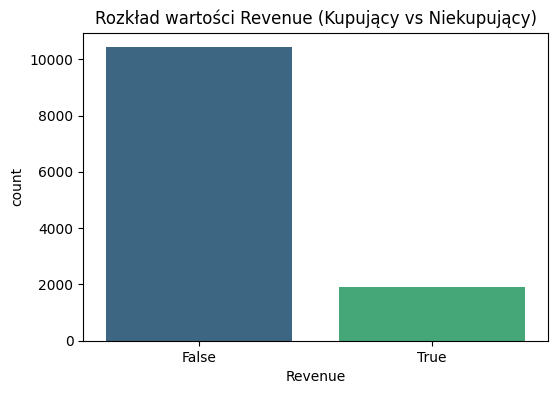

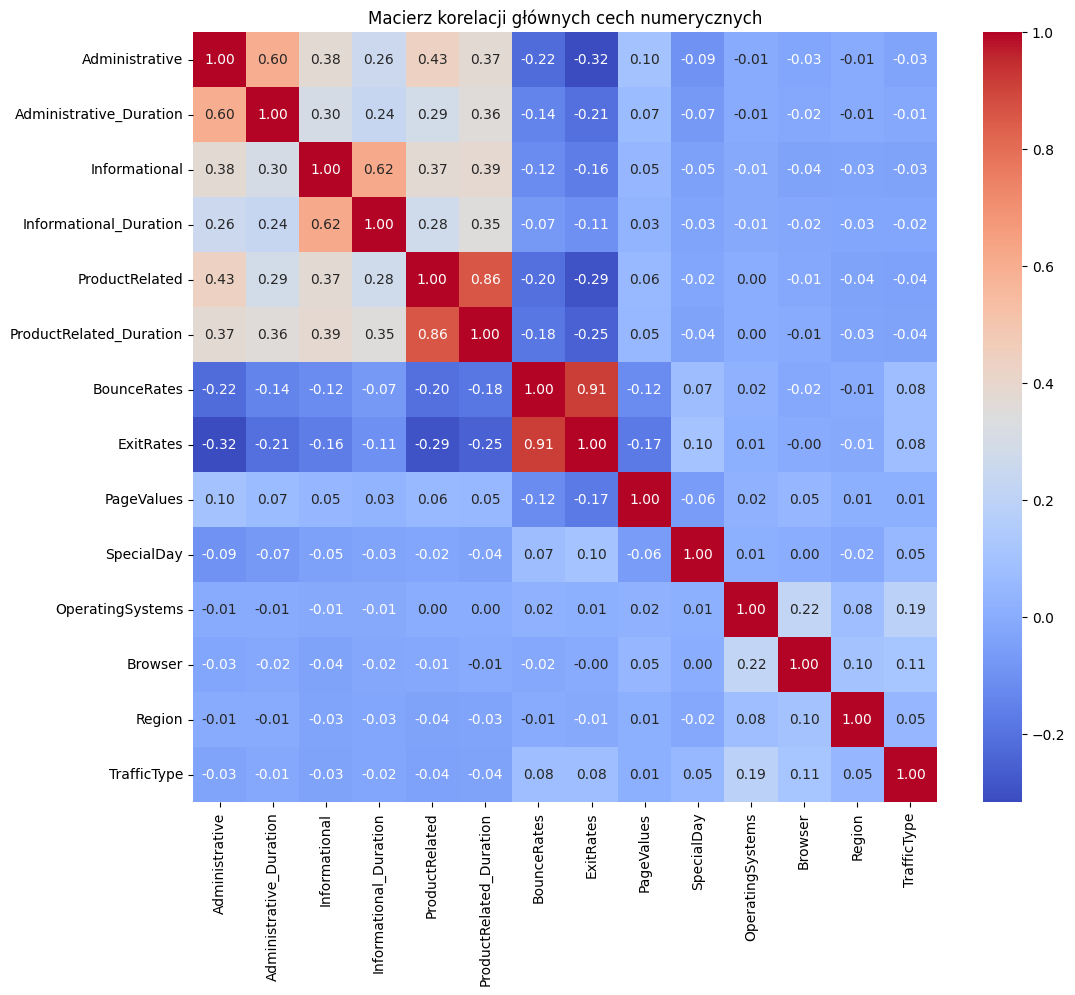

In [10]:
# 1. Wykres balansu klas
plt.figure(figsize=(6, 4))
sns.countplot(x='Revenue', data=df, palette='viridis')
plt.title('Rozkład wartości Revenue (Kupujący vs Niekupujący)')
plt.show()

# 2. Macierz korelacji głównych cech numerycznych
plt.figure(figsize=(12, 10))
# Generujemy macierz korelacji tylko dla cech numerycznych oryginalnego zbioru
correlation_matrix = df.select_dtypes(include='number').corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Macierz korelacji głównych cech numerycznych')
plt.show()

# Split data into X, y

In [4]:
# Oddzielenie cech (X) od zmiennej docelowej (y)
# Usuwamy 'Month', bo zaraz dodamy go w formie Sin/Cos
X = df.drop(columns=["Revenue", "Month"])
y = df["Revenue"].astype(int)

# Transform and preprocess data

We can express cyclical values as trigonometric values to show "closeness" of Jan and Dec.
We use OHE and Standard Scaler

In [ ]:
# Transformacja miesięcy
month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
df_months = df['Month'].map(month_map).fillna(0) 

def sin_cos_transformer(column):
    sin_feat = np.sin(2 * np.pi * column / 12)
    cos_feat = np.cos(2 * np.pi * column / 12)
    return np.column_stack([sin_feat, cos_feat])

transformer = FunctionTransformer(sin_cos_transformer)
encoded_months = transformer.fit_transform(df_months)
X['Month_Sin'] = encoded_months[:, 0]
X['Month_Cos'] = encoded_months[:, 1]

# Zamiana zmiennej logicznej Weekend na int (0/1)
X['Weekend'] = X['Weekend'].astype(int)

# Definicja kolumn kategorycznych i numerycznych
categorical_cols = ['VisitorType']
numerical_cols = X.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()

# ColumnTransformer dla ujednoliconego preprocessingu (OHE + Skalowanie)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

X_processed = preprocessor.fit_transform(X)
feature_names = numerical_cols + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols))
X_processed_df = pd.DataFrame(X_processed, columns=feature_names)

X_processed_df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend,Month_Sin,Month_Cos,VisitorType_Other,VisitorType_Returning_Visitor
0,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,-1.233426,-0.790293,-0.894178,-0.762629,-0.550552,1.281289,0.496991,0.0,1.0
1,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.590903,-0.457683,1.171473,-0.317178,-0.308821,-0.136078,-0.207952,-0.894178,-0.514182,-0.550552,1.281289,0.496991,0.0,1.0
2,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,2.058618,-0.790293,2.437081,-0.265735,-0.550552,1.281289,0.496991,0.0,1.0
3,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.622954,0.573535,1.994610,-0.317178,-0.308821,0.961270,-0.207952,-0.477771,-0.017289,-0.550552,1.281289,0.496991,0.0,1.0
4,-0.696993,-0.457191,-0.396478,-0.244931,-0.488636,-0.296430,-0.045196,0.142551,-0.317178,-0.308821,0.961270,0.374389,-0.894178,-0.017289,1.816360,1.281289,0.496991,0.0,1.0


<Axes: >

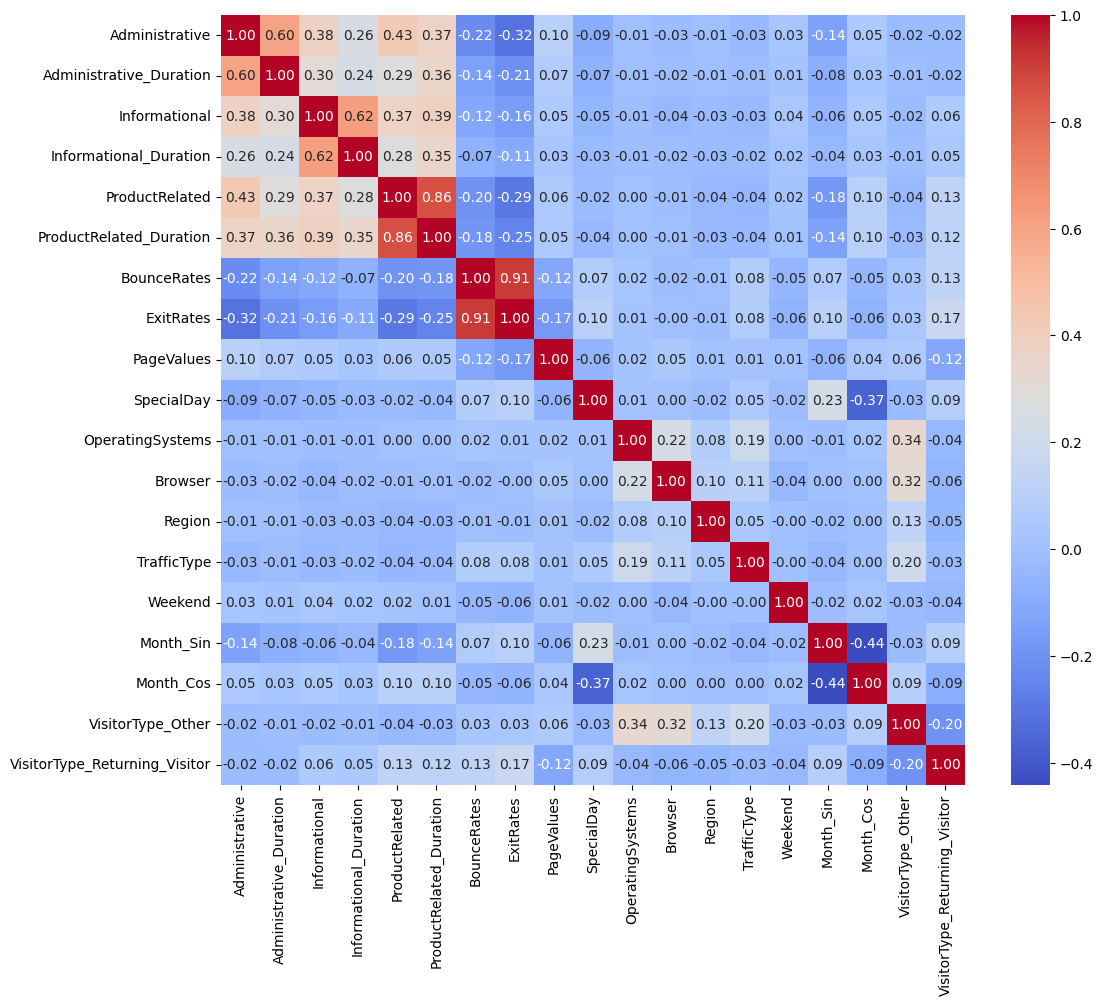

In [9]:
correlation_matrix = X_processed_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

# Training and evaluation

We define two models - Logistic Regression and Random Forest Classifier and evaluate them based on stratified 5x2 CV.

Trwa walidacja krzyżowa (5x2 CV) dla wielu metryk. Proszę czekać...


,ROC-AUC,Accuracy,Precision,Recall,F1-Score
Regresja Logistyczna,0.8917 ± 0.0052,0.8827 ± 0.0023,0.7458 ± 0.0235,0.3689 ± 0.0303,0.4924 ± 0.0238
Lasy Losowe,0.9262 ± 0.0024,0.9006 ± 0.0014,0.7471 ± 0.0104,0.5412 ± 0.0129,0.6275 ± 0.0073


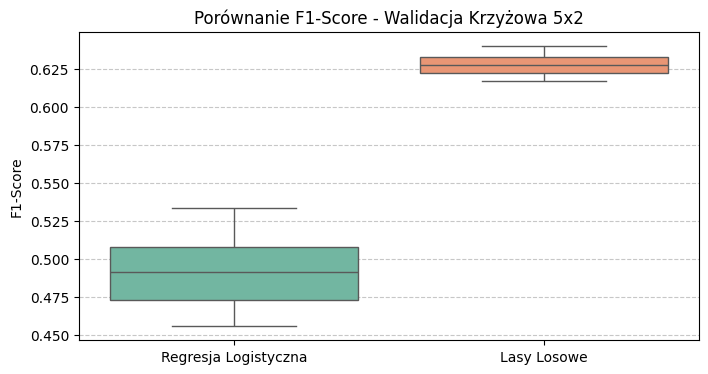

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate

# 1. Definicja modeli
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# 2. Schemat walidacji
cv_5x2 = RepeatedStratifiedKFold(n_splits=2, n_repeats=5, random_state=42)

# 3. Definicja słownika z metrykami do śledzenia
scoring = {
    'ROC-AUC': 'roc_auc',
    'Accuracy': 'accuracy',
    'Precision': 'precision',
    'Recall': 'recall',
    'F1-Score': 'f1'
}

print("Trwa walidacja krzyżowa (5x2 CV) dla wielu metryk. Proszę czekać...")

# 4. Uruchomienie cross_validate
lr_results = cross_validate(lr, X_processed_df, y, cv=cv_5x2, scoring=scoring, n_jobs=-1)
rf_results = cross_validate(rf, X_processed_df, y, cv=cv_5x2, scoring=scoring, n_jobs=-1)

# 5. Funkcja pomocnicza do tworzenia czytelnego podsumowania (DataFrame)
def create_results_df(results, model_name):
    metrics_data = {}
    for metric_name in scoring.keys():
        key = f'test_{metric_name}'
        mean_val = results[key].mean()
        std_val = results[key].std()
        metrics_data[metric_name] = f"{mean_val:.4f} ± {std_val:.4f}"
    
    df_res = pd.DataFrame(metrics_data, index=[model_name])
    return df_res

# 6. Połączenie wyników i wyświetlenie tabeli
df_lr = create_results_df(lr_results, "Regresja Logistyczna")
df_rf = create_results_df(rf_results, "Lasy Losowe")
df_final_results = pd.concat([df_lr, df_rf])

display(df_final_results)

# 7. Opcjonalnie: Zestawienie Boxplot dla wybranej metryki (np. F1-Score)
plt.figure(figsize=(8, 4))
sns.boxplot(data=[lr_results['test_F1-Score'], rf_results['test_F1-Score']], palette="Set2")
plt.xticks([0, 1], ['Regresja Logistyczna', 'Lasy Losowe'])
plt.ylabel('F1-Score')
plt.title('Porównanie F1-Score - Walidacja Krzyżowa 5x2')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()